In [ ]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import pyodbc

from sqlalchemy.engine import URL
connection_string = "DWH_name"
connection_url = URL.create("mssql+pyodbc", query={"odbc_connect": connection_string})

from sqlalchemy import create_engine
engine = create_engine(connection_url)

In [ ]:
with engine.begin() as conn:
    # Запрос 1: отключения по дням
    query1 = """
    -- отключения по дням
    select
        cast (PrevToDate as date) 'дата',
        count (distinct PrevAllo) 'отключений всего' 
    from UADMS.dbo.MSPrevNextActivations t
    where cast (PrevToDate as date) between '2024-01-01' and cast (getdate () -1 as date)
      and PrevAlloFinalEnd = 1 -- означает, что этот алло завершился (нет больше дней просмотра по нему), а не ушел в паузу 
    group by cast (PrevToDate as date)
    order by 1 
    """
    df_otkl = pd.read_sql_query(query1, conn)

    # Запрос 2: ПП день в день
    query2 = """
    select
        cast (PrevToDate as date) 'дата',
        count ( DISTINCT PrevAllo) 'ПП день в день'
    from UADMS.dbo.MSPrevNextActivations t
    where cast (PrevToDate as date) between '2024-01-01' and cast (getdate () -1 as date)
      and PrevAlloFinalEnd=1 
      and t.InactPeriod=0  -- ПОЛЕ "ПЕРИОД НЕАКТИВНОСТИ", БЕРЕМ =0
    group by cast (PrevToDate as date)
    order by 1 
    """
    df_pp = pd.read_sql_query(query2, conn)

engine.dispose()

# Объединение по дате
df_merged = pd.merge(df_otkl, df_pp, on='дата', how='outer')


# Вычисление индека ПП в процентах
df_merged['Индекс ПП'] = df_merged.apply(
    lambda row: (row['ПП день в день'] / row['отключений всего'] * 100) if row['отключений всего'] != 0 else 0,
    axis=1
)


with pd.ExcelWriter('Индекс.xlsx') as writer:
    df_merged.to_excel(writer, sheet_name='Лист1', index=False)

print("Данные успешно объединены и сохранены в 'Индекс.xlsx'")

-------------------------------------
ДЛЯ ГРАФИКОВ ИНДЕКСА
-------------------------------------

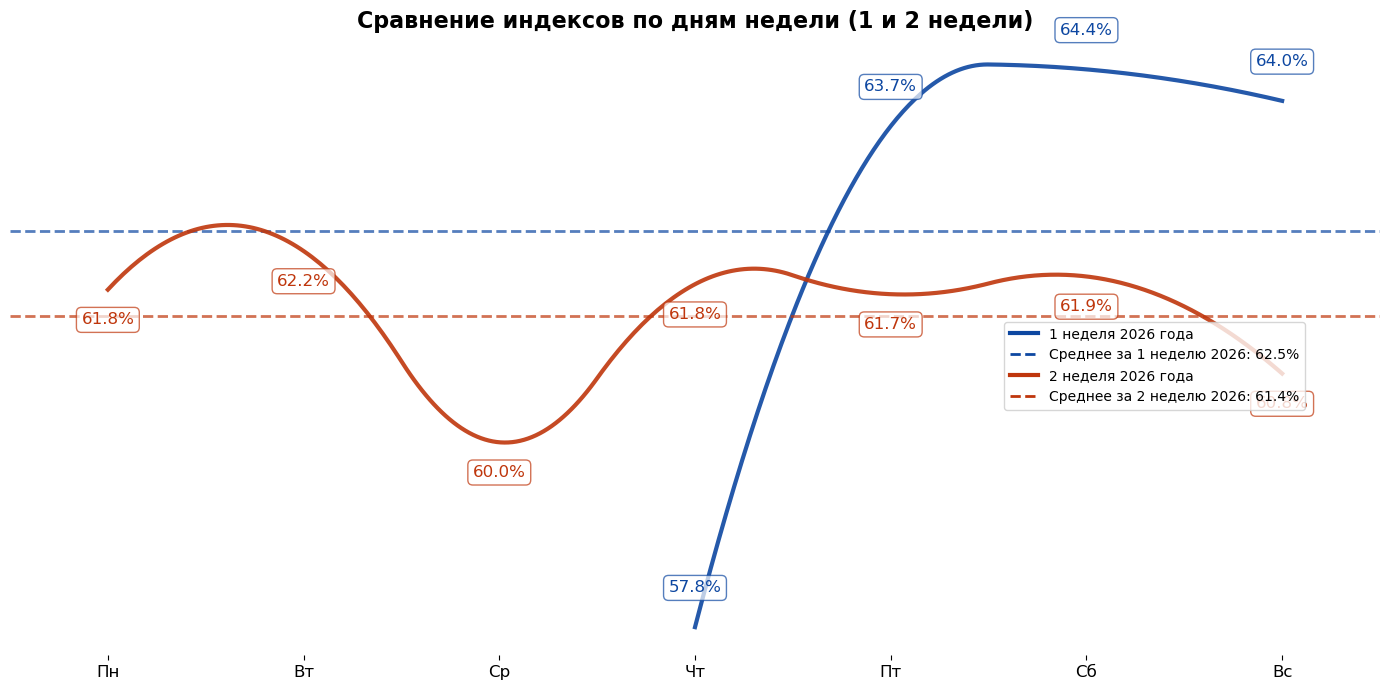

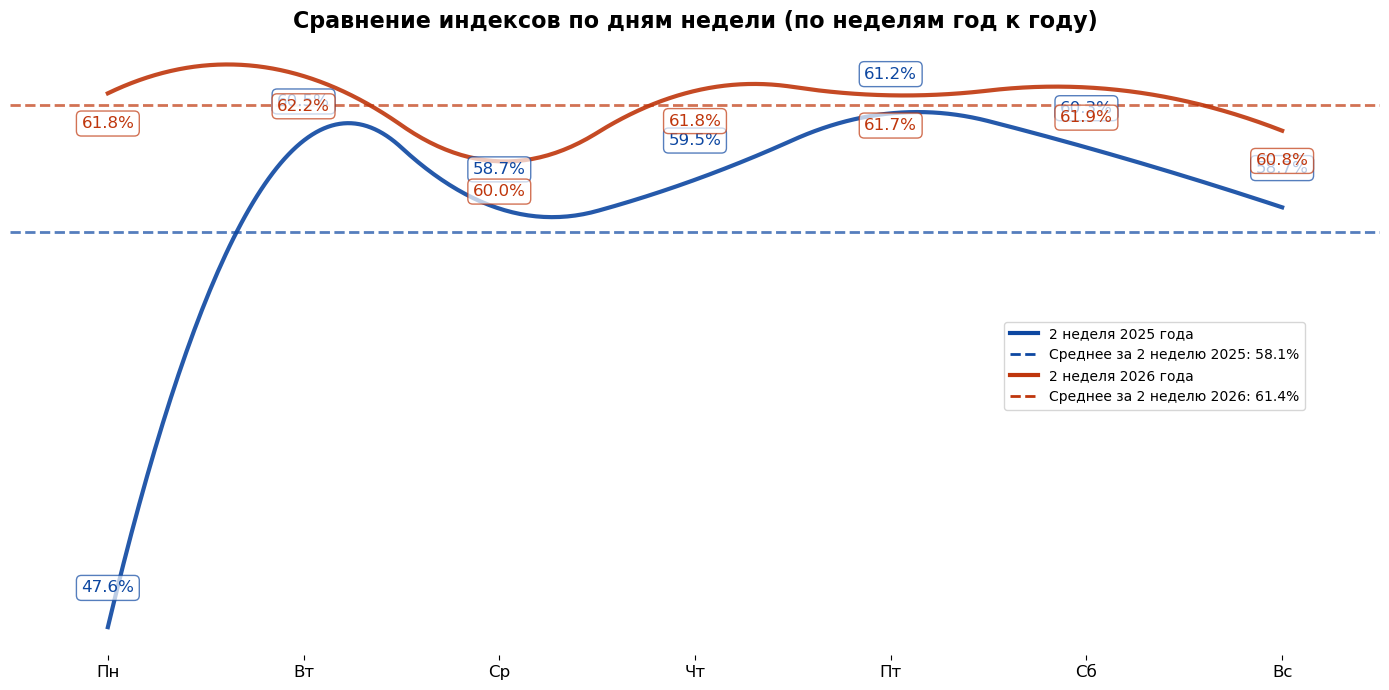

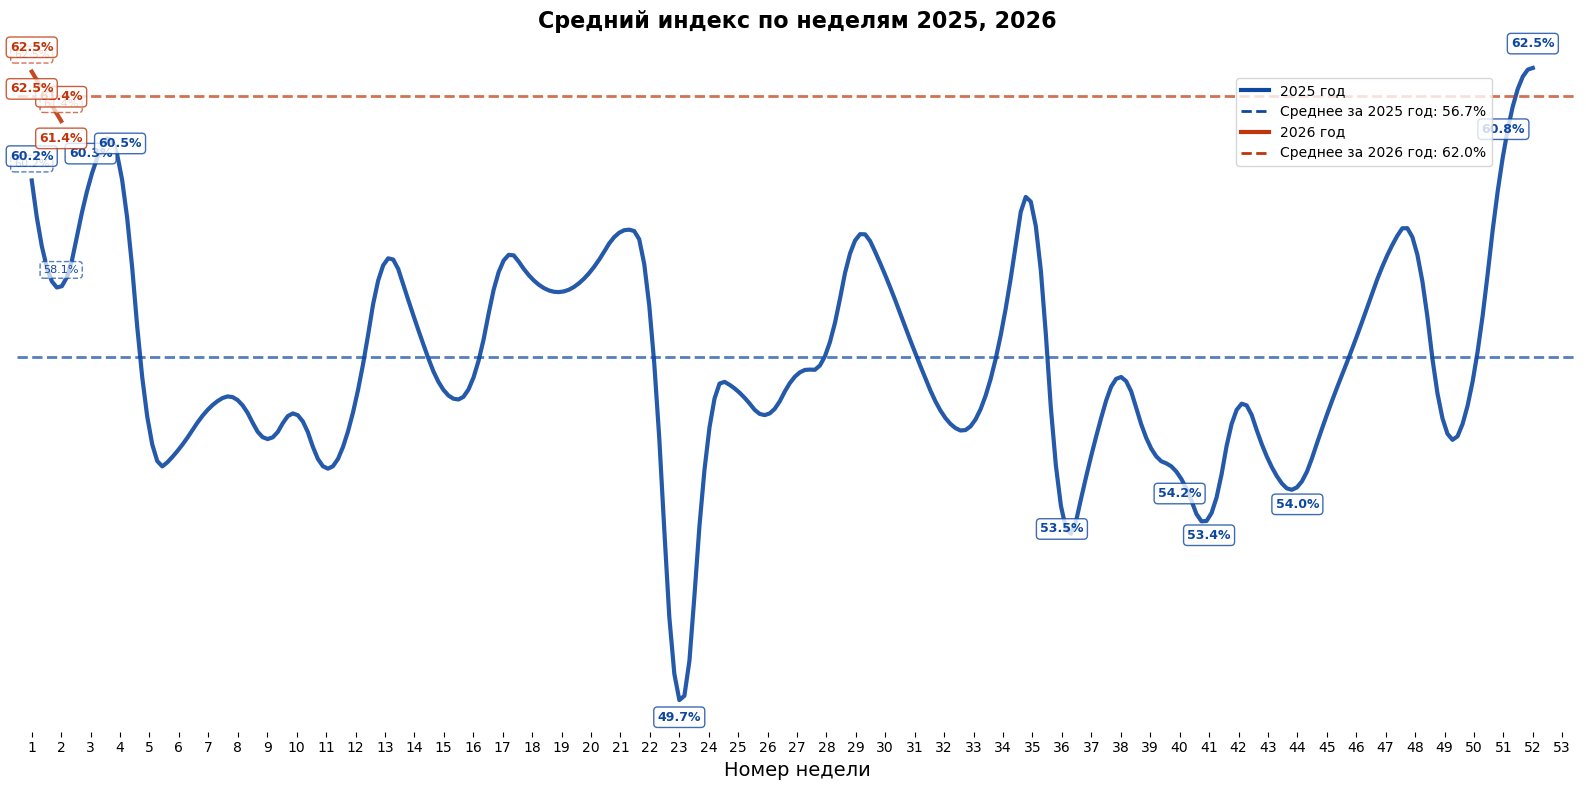

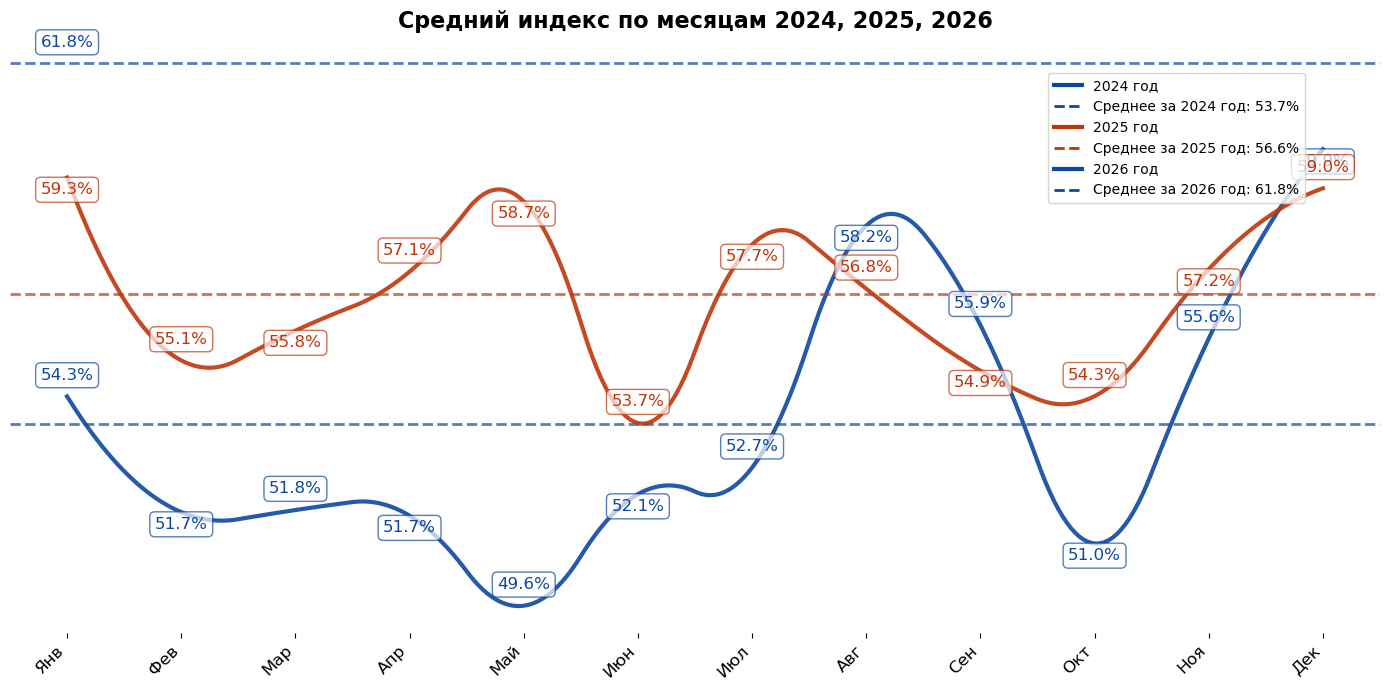

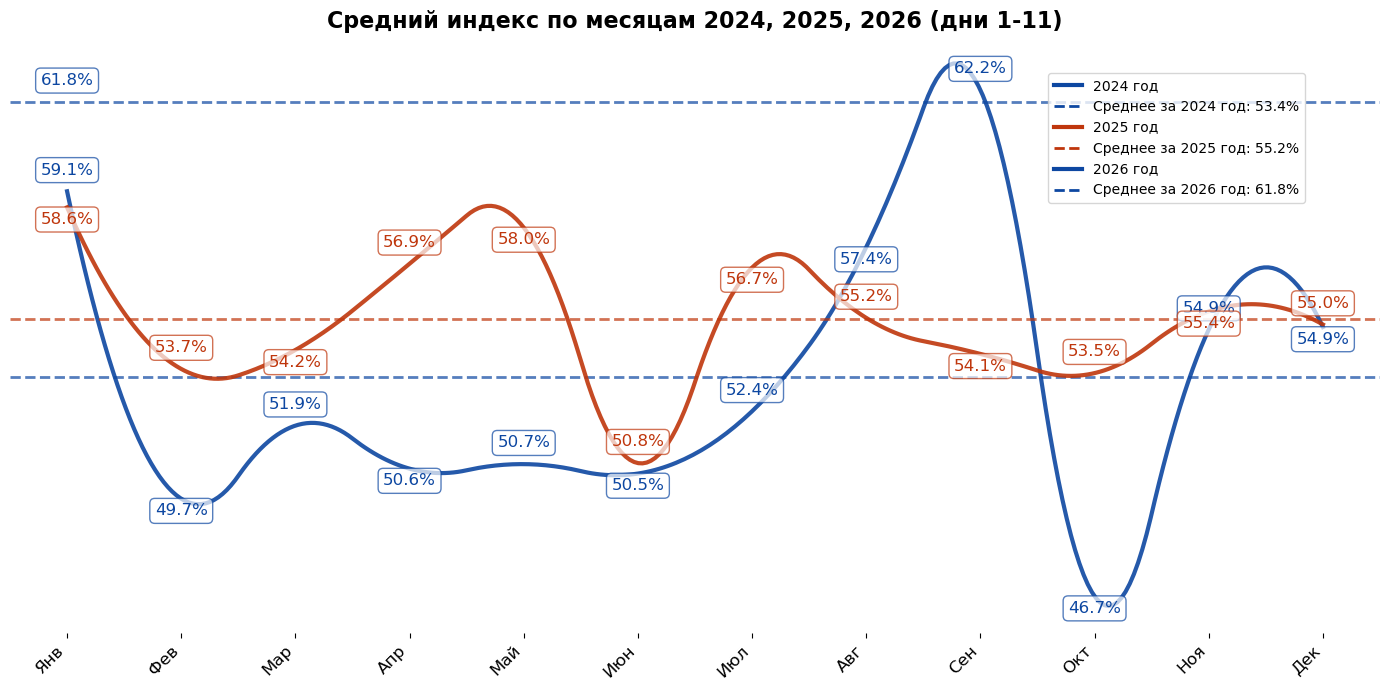

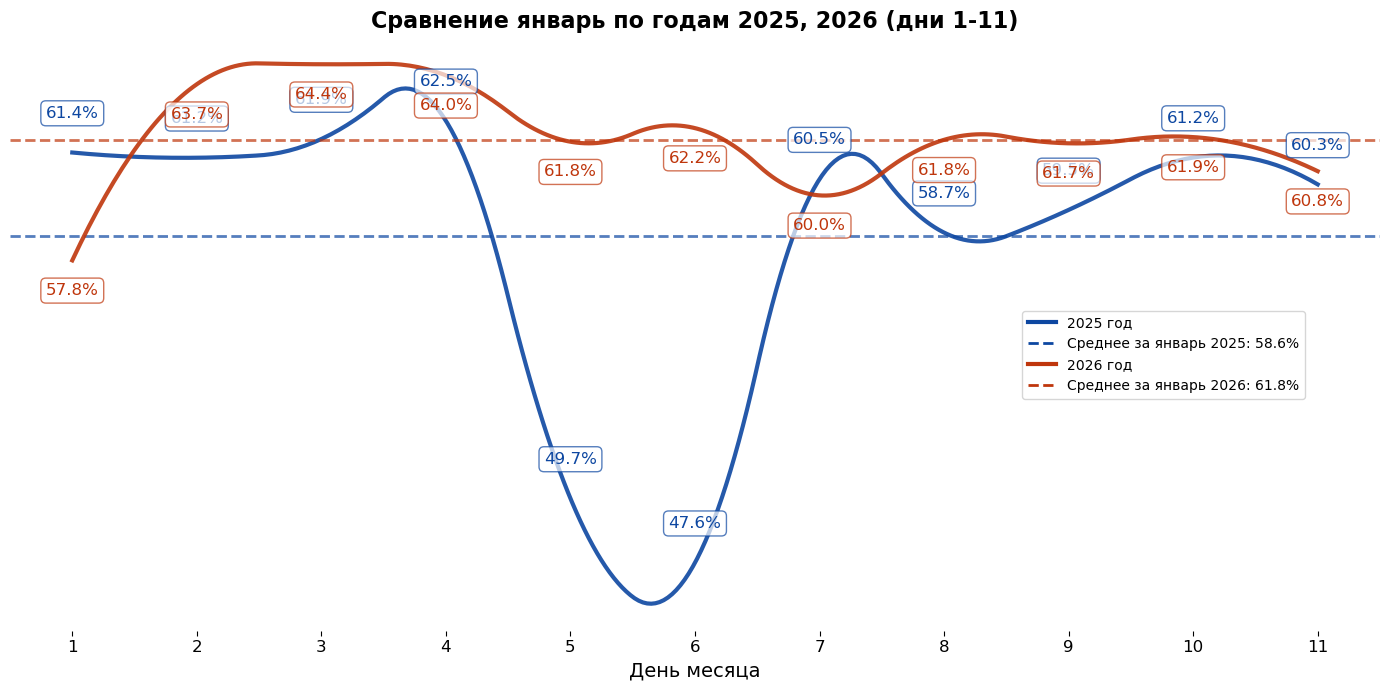

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

def prepare_data(df):
    """Подготовка данных - извлечение всех компонентов даты из столбца 'Дата'"""
    # Преобразуем столбец Дата в datetime
    df['Дата'] = pd.to_datetime(df['Дата'])
    
    # Извлекаем все компоненты даты
    df['Год'] = df['Дата'].dt.year
    df['Месяц_число'] = df['Дата'].dt.month
    df['Номер_недели'] = df['Дата'].dt.isocalendar().week
    df['День_месяца'] = df['Дата'].dt.day
    df['День_недели_число'] = df['Дата'].dt.weekday  # 0=понедельник, 6=воскресенье
    df['День_недели_название'] = df['Дата'].dt.day_name()
    
    # Словарь для русских названий месяцев
    russian_months = {
        1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
        5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
        9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
    }
    
    # Добавляем русские названия месяцев
    df['Месяц_название_рус'] = df['Месяц_число'].map(russian_months)
    
    # Конвертируем индекс в проценты (если он в формате десятичной дроби)
    df['Индекс ПП'] = df['Индекс ПП'] * 100
    
    return df

def get_color_scheme(plot_type='default'):
    """
    Гибкая настройка цветов для графиков
    
    Parameters:
    plot_type - тип графика ('default', 'weeks_comparison', 'weekly_avg', 'monthly_avg')
    
    Returns:
    Список цветов для линий
    """
    color_schemes = {
        'default': ['#0D47A1', '#BF360C'],  # Цвета как на графике "Средний индекс по неделям 2024, 2025"
        'weeks_comparison': ['#0D47A1', '#BF360C'],  # Те же цвета
        'weekly_avg': ['#0D47A1', '#BF360C'],  # Те же цвета
        'monthly_avg': ['#0D47A1', '#BF360C']  # Те же цвета
    }
    
    return color_schemes.get(plot_type, color_schemes['default'])

def smooth_line(x, y, smooth_factor=300):
    """
    Сглаживание линии с использованием сплайна
    
    Parameters:
    x - значения по оси X
    y - значения по оси Y
    smooth_factor - коэффициент сглаживания
    
    Returns:
    Сглаженные значения X и Y
    """
    if len(x) < 4:
        return x, y
    
    try:
        # Создаем сплайн для сглаживания
        x_smooth = np.linspace(min(x), max(x), smooth_factor)
        spline = make_interp_spline(x, y, k=2)
        y_smooth = spline(x_smooth)
        return x_smooth, y_smooth
    except:
        return x, y

def plot_comparison_by_weeks(df, periods, title_suffix="", colors=None):
    """
    Построение графика сравнения по неделям (аналогично дням месяца)
    
    Parameters:
    df - DataFrame с данными
    periods - список словарей с параметрами периодов для сравнения
    title_suffix - дополнительная строка для заголовка
    colors - список цветов для линий (если None, используется схема по умолчанию)
    """
    plt.figure(figsize=(14, 7))
    
    if colors is None:
        colors = get_color_scheme('weeks_comparison')
    
    # Словарь для хранения средних значений по периодам
    period_means = {}
    
    # Подготовка легенды
    legend_handles = []
    legend_labels = []
    
    for i, period in enumerate(periods):
        # Фильтрация данных по номеру недели и году
        period_data = df[
            (df['Год'] == period['год']) & 
            (df['Номер_недели'] == period['неделя'])
        ].copy()
        
        # Сортировка по дню недели (понедельник=0, воскресенье=6)
        period_data = period_data.sort_values('День_недели_число')
        
        if period_data.empty:
            continue
            
        # Расчет среднего за неделю
        period_mean = period_data['Индекс ПП'].mean()
        period_means[f"{period['неделя']} неделя {period['год']}"] = period_mean
        
        # Сглаживание линии
        x_vals = period_data['День_недели_число'].values
        y_vals = period_data['Индекс ПП'].values
        
        if len(x_vals) >= 2:
            x_smooth, y_smooth = smooth_line(x_vals, y_vals)
            
            # Построение сглаженного графика по дням недели
            plt.plot(x_smooth, y_smooth, 
                    linewidth=3, color=colors[i % len(colors)], 
                    alpha=0.9)
        else:
            plt.plot(x_vals, y_vals, 
                    linewidth=3, color=colors[i % len(colors)], 
                    alpha=0.9)
        
        # Добавляем сплошную линию в легенду
        legend_handles.append(plt.Line2D([0], [0], color=colors[i], linewidth=3))
        legend_labels.append(f"{period['неделя']} неделя {period['год']} года")
        
        # Линия среднего
        plt.axhline(y=period_mean, color=colors[i % len(colors)], 
                   linestyle='--', alpha=0.7, linewidth=2)
        
        # Добавляем пунктирную линию в легенду
        legend_handles.append(plt.Line2D([0], [0], color=colors[i], linestyle='--', linewidth=2))
        legend_labels.append(f"Среднее за {period['неделя']} неделю {period['год']}: {period_mean:.1f}%")
    
    # Добавление подписей для всех значений
    for i, period in enumerate(periods):
        period_data = df[
            (df['Год'] == period['год']) & 
            (df['Номер_недели'] == period['неделя'])
        ].copy()
        
        if period_data.empty:
            continue
            
        period_data = period_data.sort_values('День_недели_число')
        
        for _, row in period_data.iterrows():
            # Случайное смещение по вертикали чтобы избежать наложения
            vertical_offset = 25 if i % 2 == 0 else -25
            plt.annotate(f'{row["Индекс ПП"]:.1f}%', 
                        (row['День_недели_число'], row['Индекс ПП']), 
                        textcoords="offset points", 
                        xytext=(0, vertical_offset), 
                        ha='center', fontsize=12, color=colors[i % len(colors)],
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                                 edgecolor=colors[i % len(colors)], alpha=0.7))
    
    # Настройка графика
    plt.title(f'Сравнение индексов по дням недели{title_suffix}', fontsize=16, fontweight='bold')
    plt.xlabel('', fontsize=14)
    plt.ylabel('Индекс, %', fontsize=14)
    
    # Легенда
    plt.legend(legend_handles, legend_labels, fontsize=10, loc='upper right', 
               bbox_to_anchor=(0.95, 0.55))
    
    # Убраны: сетка, шкалы, рамка, ось Y
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    # Настройка оси X (дни недели)
    plt.xticks(range(0, 7), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'], fontsize=12)
    plt.xlim(-0.5, 6.5)
    
    # Убираем всю рамку и ось Y
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Убираем ось Y полностью
    plt.gca().yaxis.set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_weekly_average_index_multiyear(df, years=None, title_suffix="", colors=None):
    """
    Построение графика среднего индекса по неделям для нескольких лет на одном графике
    
    Parameters:
    df - DataFrame с данными
    years - список годов для отображения (если None, то все доступные годы)
    title_suffix - дополнительная строка для заголовка
    colors - список цветов для линий (если None, используется схема по умолчанию)
    """
    # Фильтрация по годам если указаны
    if years is not None:
        df_filtered = df[df['Год'].isin(years)].copy()
        years_label = f" {', '.join(map(str, years))}"
    else:
        df_filtered = df.copy()
        available_years = sorted(df['Год'].unique())
        years_label = f" {', '.join(map(str, available_years))}"
    
    # Сортируем годы по возрастанию
    years = sorted(years) if years else sorted(df_filtered['Год'].unique())
    
    # Группировка по году и неделе, расчет среднего индекса
    weekly_avg = df_filtered.groupby(['Год', 'Номер_недели'])['Индекс ПП'].mean().reset_index()
    
    plt.figure(figsize=(16, 8))
    
    if colors is None:
        colors = get_color_scheme('weekly_avg')
    
    # Для каждого года определяем экстремумы
    all_annotations_data = []
    legend_handles = []
    legend_labels = []
    
    # Определяем номер последней недели в последнем периоде
    # Ищем максимальную неделю среди всех данных за последний год
    last_year = max(years)
    last_year_data = weekly_avg[weekly_avg['Год'] == last_year]
    
    if not last_year_data.empty:
        # Находим максимальную неделю за последний год
        last_week = int(last_year_data['Номер_недели'].max())
    else:
        # Если нет данных за последний год, берем максимальную неделю из всех данных
        last_week = int(weekly_avg['Номер_недели'].max())
    
    # Определяем диапазон последних 4 недель
    start_week = max(1, last_week - 3)
    end_week = last_week
    
    # Построение графика для каждого года
    for i, year in enumerate(years):
        year_data = weekly_avg[weekly_avg['Год'] == year].copy()
        year_data = year_data.sort_values('Номер_недели')
        
        if year_data.empty:
            continue
            
        color = colors[i % len(colors)]
        
        # Расчет среднего за год
        year_mean = year_data['Индекс ПП'].mean()
        
        # Сглаживание линии
        x_vals = year_data['Номер_недели'].values
        y_vals = year_data['Индекс ПП'].values
        
        if len(x_vals) >= 4:
            x_smooth, y_smooth = smooth_line(x_vals, y_vals, smooth_factor=300)
            
            # Построение сглаженного графика
            plt.plot(x_smooth, y_smooth, 
                     linewidth=3, markersize=0, color=color,
                     alpha=0.9)
            
            # Линия среднего
            plt.axhline(y=year_mean, color=color, 
                       linestyle='--', alpha=0.7, linewidth=2)
            
            # Для аннотаций используем исходные данные
            plot_x = x_vals
            plot_y = y_vals
        else:
            plt.plot(x_vals, y_vals, 
                     linewidth=3, markersize=0, color=color,
                     alpha=0.9)
            
            # Линия среднего
            plt.axhline(y=year_mean, color=color, 
                       linestyle='--', alpha=0.7, linewidth=2)
            
            plot_x = x_vals
            plot_y = y_vals
        
        # Добавляем сплошную линию в легенду
        legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=3))
        legend_labels.append(f"{year} год")
        
        # Добавляем пунктирную линию среднего в легенду
        legend_handles.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=2))
        legend_labels.append(f"Среднее за {year} год: {year_mean:.1f}%")
        
        # Определяем 5 верхних и 5 нижних экстремумов
        if len(plot_y) >= 10:
            # Индексы 5 максимальных значений
            max_indices = np.argsort(plot_y)[-5:]
            # Индексы 5 минимальных значений
            min_indices = np.argsort(plot_y)[:5]
        else:
            # Если данных меньше 10, берем 2 максимума и 2 минимума
            max_indices = np.argsort(plot_y)[-2:]
            min_indices = np.argsort(plot_y)[:2]
        
        # Добавляем последние 4 недели для каждого года
        # Ищем недели в диапазоне [start_week, end_week] для текущего года
        last_weeks_data = year_data[
            (year_data['Номер_недели'] >= start_week) & 
            (year_data['Номер_недели'] <= end_week)
        ]
        
        for _, row in last_weeks_data.iterrows():
            all_annotations_data.append({
                'year': year,
                'x': row['Номер_недели'],
                'y': row['Индекс ПП'],
                'type': 'last',
                'color': color
            })
        
        # Сохраняем данные для экстремумов
        for idx in max_indices:
            all_annotations_data.append({
                'year': year,
                'x': plot_x[idx],
                'y': plot_y[idx],
                'type': 'max',
                'color': color
            })
        
        for idx in min_indices:
            all_annotations_data.append({
                'year': year,
                'x': plot_x[idx],
                'y': plot_y[idx],
                'type': 'min',
                'color': color
            })
    
    # Нанесение аннотаций
    for ann_data in all_annotations_data:
        # Определяем смещение в зависимости от типа аннотации
        if ann_data['type'] == 'max':
            offset_y = 15
            weight = 'bold'
            fontsize = 9
            bbox_style = dict(boxstyle="round,pad=0.3", facecolor='white', 
                            edgecolor=ann_data['color'], alpha=0.8)
        elif ann_data['type'] == 'min':
            offset_y = -15
            weight = 'bold'
            fontsize = 9
            bbox_style = dict(boxstyle="round,pad=0.3", facecolor='white', 
                            edgecolor=ann_data['color'], alpha=0.8)
        else:  # 'last' - последние недели
            offset_y = 10 if hash(str(ann_data['year'])) % 2 == 0 else -10
            weight = 'normal'
            fontsize = 8
            bbox_style = dict(boxstyle="round,pad=0.3", facecolor='white', 
                            edgecolor=ann_data['color'], alpha=0.7, linestyle='--')
        
        plt.annotate(f'{ann_data["y"]:.1f}%', 
                    (ann_data['x'], ann_data['y']), 
                    textcoords="offset points", 
                    xytext=(0, offset_y),
                    ha='center', 
                    fontsize=fontsize,
                    color=ann_data['color'],
                    weight=weight,
                    bbox=bbox_style)
    
    # Настройка графика
    plt.title(f'Средний индекс по неделям{years_label}{title_suffix}', fontsize=16, fontweight='bold')
    plt.xlabel('Номер недели', fontsize=14)
    plt.ylabel('Средний индекс, %', fontsize=14)
    
    # Легенда
    plt.legend(legend_handles, legend_labels, fontsize=10, loc='upper right', 
               bbox_to_anchor=(0.95, 0.95))
    
    # Убраны: сетка, шкалы, рамка, ось Y
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    # Настройка оси X - отображаем номера всех недель
    plt.xticks(range(1, 54), fontsize=10)
    plt.xlim(0.5, 53.5)
    
    # Убираем всю рамку и ось Y
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Убираем ось Y полностью
    plt.gca().yaxis.set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_monthly_average_index_multiyear(df, years=None, day_range=None, title_suffix="", colors=None):
    """
    Построение графика среднего индекса по месяцам для нескольких лет на одном графике
    
    Parameters:
    df - DataFrame с данными
    years - список годов для отображения (если None, то все доступные годы)
    day_range - словарь с диапазоном дней {'start': X, 'end': Y} (если None, то все дни месяца)
    title_suffix - дополнительная строка для заголовка
    colors - список цветов для линий (если None, используется схема по умолчанию)
    """
    # Фильтрация по годам если указаны
    if years is not None:
        df_filtered = df[df['Год'].isin(years)].copy()
        years_label = f" {', '.join(map(str, years))}"
    else:
        df_filtered = df.copy()
        available_years = sorted(df['Год'].unique())
        years_label = f" {', '.join(map(str, available_years))}"
    
    # Фильтрация по диапазону дней если указан
    if day_range is not None:
        start_day = day_range.get('start', 1)
        end_day = day_range.get('end', 31)
        df_filtered = df_filtered[
            (df_filtered['День_месяца'] >= start_day) & 
            (df_filtered['День_месяца'] <= end_day)
        ]
        day_range_label = f" (дни {start_day}-{end_day})"
    else:
        day_range_label = ""
    
    # Группировка по году и месяцу, расчет среднего индекса
    monthly_avg = df_filtered.groupby(['Год', 'Месяц_число', 'Месяц_название_рус'])['Индекс ПП'].mean().reset_index()
    
    plt.figure(figsize=(14, 7))
    
    if colors is None:
        colors = get_color_scheme('monthly_avg')
    
    # Словарь для порядка месяцев
    month_order = {
        'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4,
        'Май': 5, 'Июнь': 6, 'Июль': 7, 'Август': 8,
        'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12
    }
    
    # Подготовка легенды
    legend_handles = []
    legend_labels = []
    
    # Построение графика для каждого года
    for i, year in enumerate(sorted(monthly_avg['Год'].unique())):
        year_data = monthly_avg[monthly_avg['Год'] == year].copy()
        year_data['month_order'] = year_data['Месяц_название_рус'].map(month_order)
        year_data = year_data.sort_values('month_order')
        
        if year_data.empty:
            continue
            
        color = colors[i % len(colors)]
        
        # Расчет среднего за год
        year_mean = year_data['Индекс ПП'].mean()
        
        # Преобразуем месяцы в числовой формат для сглаживания
        x_numeric = year_data['Месяц_число'].values
        y_vals = year_data['Индекс ПП'].values
        
        # Сглаживание линии (используем числовые значения месяцев)
        if len(x_numeric) >= 2:
            x_smooth, y_smooth = smooth_line(x_numeric, y_vals, smooth_factor=300)
            
            # Построение сглаженного графика
            plt.plot(x_smooth, y_smooth, 
                     linewidth=3, markersize=0, color=color,
                     alpha=0.9)
            
            # Линия среднего
            plt.axhline(y=year_mean, color=color, 
                       linestyle='--', alpha=0.7, linewidth=2)
        else:
            plt.plot(x_numeric, y_vals, 
                     linewidth=3, markersize=0, color=color,
                     alpha=0.9)
            
            # Линия среднего
            plt.axhline(y=year_mean, color=color, 
                       linestyle='--', alpha=0.7, linewidth=2)
        
        # Добавляем сплошную линию в легенду
        legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=3))
        legend_labels.append(f"{year} год")
        
        # Добавляем пунктирную линию среднего в легенду
        legend_handles.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=2))
        legend_labels.append(f"Среднее за {year} год: {year_mean:.1f}%")
    
    # Добавление подписей для всех значений на графике по месяцам
    for i, year in enumerate(sorted(monthly_avg['Год'].unique())):
        year_data = monthly_avg[monthly_avg['Год'] == year].copy()
        year_data['month_order'] = year_data['Месяц_название_рус'].map(month_order)
        year_data = year_data.sort_values('month_order')
        
        if year_data.empty:
            continue
            
        color = colors[i % len(colors)]
        
        for j, row in year_data.iterrows():
            # Находим позицию месяца на графике
            month_num = row['Месяц_число']
            
            # Чередуем смещение для разных лет чтобы избежать наложения
            vertical_offset = 12 if (i + j) % 2 == 0 else -12
            plt.annotate(f'{row["Индекс ПП"]:.1f}%', 
                        (month_num, row['Индекс ПП']),  # Используем числовое значение месяца
                        textcoords="offset points", 
                        xytext=(0, vertical_offset), 
                        ha='center', fontsize=12, color=color,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                                 edgecolor=color, alpha=0.7))
    
    # Настройка графика
    plt.title(f'Средний индекс по месяцам{years_label}{day_range_label}{title_suffix}', fontsize=16, fontweight='bold')
    plt.xlabel('', fontsize=14)
    plt.ylabel('Средний индекс, %', fontsize=14)
    
    # Легенда
    plt.legend(legend_handles, legend_labels, fontsize=10, loc='upper right', 
               bbox_to_anchor=(0.95, 0.95))
    
    # Убраны: сетка, шкалы, рамка, ось Y
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    # Настройка оси X - используем числовые значения месяцев
    month_short_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                        'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
    plt.xticks(range(1, 13), month_short_names, rotation=45, ha='right', fontsize=12)
    plt.xlim(0.5, 12.5)
    
    # Убираем всю рамку и ось Y
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Убираем ось Y полностью
    plt.gca().yaxis.set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_specific_month_comparison(df, month, years=None, day_range=None, title_suffix="", colors=None):
    """
    Построение графика сравнения конкретного месяца в разных годах по дням месяца
    
    Parameters:
    df - DataFrame с данными
    month - номер месяца (1-12)
    years - список годов для отображения (если None, то все доступные годы)
    day_range - словарь с диапазоном дней {'start': X, 'end': Y} (если None, то все дни месяца)
    title_suffix - дополнительная строка для заголовка
    colors - список цветов для линий (если None, используется схема по умолчанию)
    """
    # Фильтрация по месяцу
    df_month = df[df['Месяц_число'] == month].copy()
    
    # Фильтрация по годам если указаны
    if years is not None:
        df_month = df_month[df_month['Год'].isin(years)].copy()
        years_label = f" {', '.join(map(str, years))}"
    else:
        available_years = sorted(df_month['Год'].unique())
        years_label = f" {', '.join(map(str, available_years))}"
        years = available_years
    
    # Фильтрация по диапазону дней если указан
    if day_range is not None:
        start_day = day_range.get('start', 1)
        end_day = day_range.get('end', 31)
        df_month = df_month[
            (df_month['День_месяца'] >= start_day) & 
            (df_month['День_месяца'] <= end_day)
        ]
        day_range_label = f" (дни {start_day}-{end_day})"
    else:
        day_range_label = ""
    
    # Русское название месяца
    russian_months = {
        1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель',
        5: 'Май', 6: 'Июнь', 7: 'Июль', 8: 'Август',
        9: 'Сентябрь', 10: 'Октябрь', 11: 'Ноябрь', 12: 'Декабрь'
    }
    month_name = russian_months.get(month, f"Месяц {month}")
    
    plt.figure(figsize=(14, 7))
    
    if colors is None:
        colors = get_color_scheme('default')
    
    # Подготовка легенды
    legend_handles = []
    legend_labels = []
    
    # Построение графика для каждого года
    for i, year in enumerate(sorted(years)):
        # Фильтрация данных по году
        year_data = df_month[df_month['Год'] == year].copy()
        
        # Сортировка по дню месяца
        year_data = year_data.sort_values('День_месяца')
        
        if year_data.empty:
            continue
            
        color = colors[i % len(colors)]
        
        # Расчет среднего за месяц для этого года
        month_mean = year_data['Индекс ПП'].mean()
        
        # Сглаживание линии
        x_vals = year_data['День_месяца'].values
        y_vals = year_data['Индекс ПП'].values
        
        if len(x_vals) >= 2:
            x_smooth, y_smooth = smooth_line(x_vals, y_vals)
            
            # Построение сглаженного графика по дням месяца
            plt.plot(x_smooth, y_smooth, 
                    linewidth=3, color=color, 
                    alpha=0.9)
        else:
            plt.plot(x_vals, y_vals, 
                    linewidth=3, color=color, 
                    alpha=0.9)
        
        # Добавляем сплошную линию в легенду
        legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=3))
        legend_labels.append(f"{year} год")
        
        # Линия среднего за месяц
        plt.axhline(y=month_mean, color=color, 
                   linestyle='--', alpha=0.7, linewidth=2)
        
        # Добавляем пунктирную линию в легенду
        legend_handles.append(plt.Line2D([0], [0], color=color, linestyle='--', linewidth=2))
        legend_labels.append(f"Среднее за {month_name.lower()} {year}: {month_mean:.1f}%")
    
    # Добавление подписей для всех значений
    for i, year in enumerate(sorted(years)):
        year_data = df_month[df_month['Год'] == year].copy()
        year_data = year_data.sort_values('День_месяца')
        
        if year_data.empty:
            continue
            
        color = colors[i % len(colors)]
        
        for _, row in year_data.iterrows():
            # Случайное смещение по вертикали чтобы избежать наложения
            vertical_offset = 25 if i % 2 == 0 else -25
            plt.annotate(f'{row["Индекс ПП"]:.1f}%', 
                        (row['День_месяца'], row['Индекс ПП']), 
                        textcoords="offset points", 
                        xytext=(0, vertical_offset), 
                        ha='center', fontsize=12, color=color,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                                 edgecolor=color, alpha=0.7))
    
    # Настройка графика
    plt.title(f'Сравнение {month_name.lower()} по годам{years_label}{day_range_label}{title_suffix}', 
              fontsize=16, fontweight='bold')
    plt.xlabel('День месяца', fontsize=14)
    plt.ylabel('Индекс, %', fontsize=14)
    
    # Легенда
    plt.legend(legend_handles, legend_labels, fontsize=10, loc='upper right', 
               bbox_to_anchor=(0.95, 0.55))
    
    # Убраны: сетка, шкалы, рамка, ось Y
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    
    # Настройка оси X (дни месяца)
    # Определяем максимальный день в данных
    max_day = df_month['День_месяца'].max()
    x_ticks = range(1, min(max_day, 31) + 1)
    plt.xticks(x_ticks, fontsize=12)
    plt.xlim(0.5, max_day + 0.5)
    
    # Убираем всю рамку и ось Y
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    
    # Убираем ось Y полностью
    plt.gca().yaxis.set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Основная часть скрипта
if __name__ == "__main__":
    # Чтение файла из листа "Лист1" где находятся расчеты индекса
    df = pd.read_excel('Индекс.xlsx', sheet_name='Лист1')
    
    # Подготовка данных
    df = prepare_data(df)

    # 1. Сравнение по неделям прошлая к предыдущей
    periods_weeks = [
        {'год': 2026, 'неделя': 1},
        {'год': 2026, 'неделя': 2}
    ]
    # Используем те же цвета что и на графике "Средний индекс по неделям"
    custom_colors = get_color_scheme('default')
    plot_comparison_by_weeks(df, periods_weeks, " (1 и 2 недели)", colors=custom_colors)

    # 2. Сравнение по неделям год к году
    periods_weeks = [
        {'год': 2025, 'неделя': 2},
        {'год': 2026, 'неделя': 2}
    ]
    # Используем те же цвета
    plot_comparison_by_weeks(df, periods_weeks, " (по неделям год к году)", colors=custom_colors)

    # 3. Графики среднего индекса по неделям и месяцам для нескольких лет
    
    # Получаем доступные годы из данных
    available_years = sorted(df['Год'].unique())
    
    # График по неделям для всех доступных лет (только 2025, 2026)
    years_to_plot = [year for year in available_years if year in [2025, 2026]]
    if years_to_plot:
        # Используем те же цвета
        plot_weekly_average_index_multiyear(df, years=years_to_plot, 
                                          title_suffix="", colors=custom_colors)
    
    # График по месяцам для всех доступных лет (все дни месяца)
    # Используем те же цвета
    plot_monthly_average_index_multiyear(df, years=available_years, 
                                       title_suffix="", colors=custom_colors)
    
    # График по месяцам для всех доступных лет (первые 11 дней)
    plot_monthly_average_index_multiyear(df, years=available_years, 
                                       day_range={'start': 1, 'end': 11}, 
                                       title_suffix="", colors=custom_colors)
    
    # 4. Новый график: сравнение конкретного месяца по годам
    # Пример: сравнение января (месяц=1) за 2025 и 2026 годы
    plot_specific_month_comparison(df, month=1, years=[2025, 2026], 
                                  day_range={'start': 1, 'end': 11},
                                  title_suffix="", colors=custom_colors)
    
    # Пример 2: сравнение февраля за все доступные годы
    # plot_specific_month_comparison(df, month=2, years=None, 
    #                               day_range={'start': 1, 'end': 28},
    #                               title_suffix="", colors=custom_colors)